# Setup

In [ ]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# import tpvalidator.workspace as workspace
# import tpvalidator.analysis.snn as snn
import hist
import mplhep as hep


from rich import print
from matplotlib.colors import LogNorm
from tpvalidator.analysis.histograms import cumsum_hist, linspace, compute_regaxis_specs

from tpvalidator.viz.tps import TrgPrimitivesPlotter
from typing import Literal


# Data

In [3]:
import tpvalidator.datacatalogue as dctl

dataset_names = ['eminus', 'radbkg']
datasets = dctl.load('data/vd/1x8x14/3sig', dataset_names)
rad_ws=datasets['radbkg']
em_ws=datasets['eminus']


Workspace ar39 skipped

Workspace ar39_5e_00 skipped

Loading radbkg

Dataset 'radbkg': 10 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [
        [28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
        [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
        [26, 'Kr85GenInLAr'],
        [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
        [24, 'U238ChainGenInAnode'],
        [23, 'K40GenInCathode'],
        [22, 'K42From42ArGenInUpperMesh1x8x14'],
        [21, 'Th232ChainGenInCathode'],
        [20, 'CavernNGammasAtLAr1x8x14'],
        [19, 'Rn222ChainRn222GenInLAr'],
        [18, 'U238ChainGenInCathode'],
        [17, 'K40GenInAnode'],
        [16, 'Rn220ChainPb212GenInLAr'],
        [15, 'foamGammasAtLAr1x8x14'],
        [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
        [13, 'K42From42ArGenInLAr'],
        [12, 'Rn222ChainGenInPDS'],
        [11, 'Ar42GenInLAr'],
        [10, 'CavernwallGammasAtLAr1x8x14'],
        [9, 'Rn222ChainPb210GenInLAr'],
        [8, 'Ar39GenInLAr'],
        [7, 'Rn222ChainPb214GenInLAr'],
        [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
        [5, 'Rn222ChainPo218GenInLAr'],
        [4, 'CavernwallNeutronsAtLAr1x8x14'],
        [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
        [2, 'CryostatNGammasAtLAr1x8x14'],
        [1, 'Th232ChainGenInAnode'],
        [0, 'Rn222ChainBi214GenInLAr']
    ],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 27,
            'threshold_tpg_plane1': 27,
            'threshold_tpg_plane2': 27,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Loading eminus

Dataset 'eminus': 1000 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 27,
            'threshold_tpg_plane1': 27,
            'threshold_tpg_plane2': 27,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

In [4]:
rad_ws.simides.query('entry == 0')

event    run  subrun  channel  timestamp  numelectrons  \
entry subentry                                                           
0     0             1  99001       0    95921       4204      1.291759   
      1             1  99001       0    95921       4205     25.167480   
      2             1  99001       0    95921       4206    109.515297   
      3             1  99001       0    95921       4207    151.097382   
      4             1  99001       0    95921       4208     66.423973   
...               ...    ...     ...      ...        ...           ...   
      972159        1  99001       0      863       6019   1241.739380   
      972160        1  99001       0      863       6020    697.639282   
      972161        1  99001       0      863       6021    268.969147   
      972162        1  99001       0      863       6022     71.626984   
      972163        1  99001       0      863       6023     10.025547   

                  energy           x           y            z  trackID  \
entry subentry                                                           
0     0         0.004875  204.991592  514.138367  1966.534668    25595   
      1         0.204300  204.991608  514.138428  1966.534668    25595   
      2         0.889781  204.991608  514.138428  1966.534668    25595   
      3         1.228692  204.991608  514.138428  1966.534668    25595   
      4         0.540621  204.991608  514.138428  1966.534668    25595   
...                  ...         ...         ...          ...      ...   
      972159    2.619871  -26.117537 -668.040161   149.617615    10738   
      972160    1.444241  -26.117876 -668.039856   149.617737    10738   
      972161    0.513324  -26.118258 -668.039673   149.617889    10738   
      972162    0.134531  -26.118591 -668.039368   149.617981    10738   
      972163    0.013571  -26.122740 -668.037537   149.618988    10738   

                origTrackID  readout_plane_id  readout_view  detector_element  \
entry subentry                                                                  
0     0             25595.0               0.0           0.0             111.0   
      1             25595.0               0.0           0.0             111.0   
      2             25595.0               0.0           0.0             111.0   
      3             25595.0               0.0           0.0             111.0   
      4             25595.0               0.0           0.0             111.0   
...                     ...               ...           ...               ...   
      972159        10738.0               2.0           2.0               0.0   
      972160        10738.0               2.0           2.0               0.0   
      972161        10738.0               2.0           2.0               0.0   
      972162        10738.0               2.0           2.0               0.0   
      972163        10738.0               2.0           2.0               0.0   

                event_uid  
entry subentry             
0     0         216752193  
      1         216752193  
      2         216752193  
      3         216752193  
      4         216752193  
...                   ...  
      972159    216752193  
      972160    216752193  
      972161    216752193  
      972162    216752193  
      972163    216752193  

[972164 rows x 16 columns]

In [33]:
import tpvalidator.analysis.histograms as histutils


_sim_ides = rad_ws.simides.query('entry == 0')
# _sim_ides = rad_ws.simides


bin_size = 10
axes = [
    histutils._make_regaxis(_sim_ides, 'x', bin_size=bin_size),
    histutils._make_regaxis(_sim_ides, 'y', bin_size=bin_size),
    histutils._make_regaxis(_sim_ides, 'z', bin_size=bin_size),
]

ne = histutils._build_histogram(_sim_ides, axes, weight='energy')




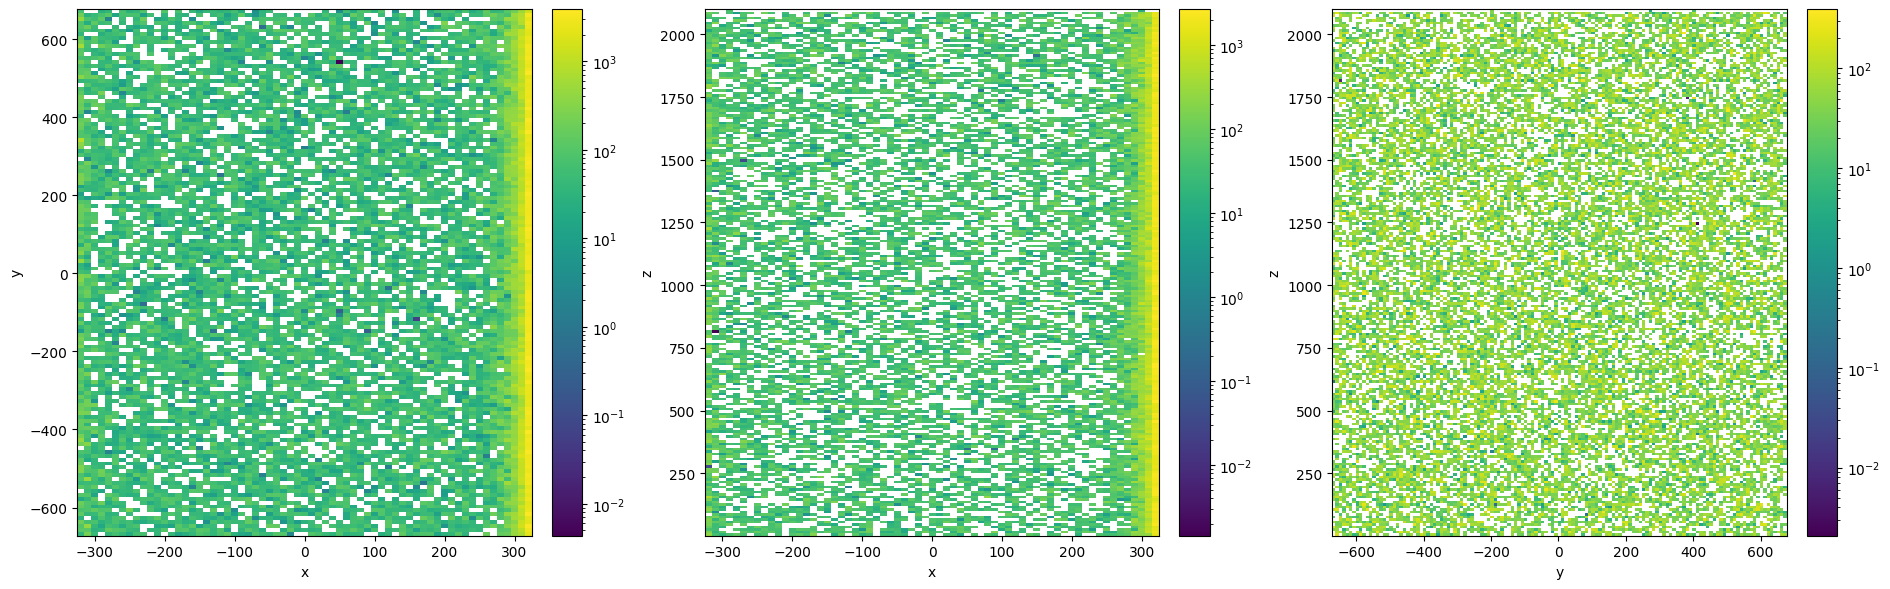

In [34]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1,3, figsize=(19, 6))


ne[:,:, sum].plot(norm=LogNorm(), ax=axes[0])

ne[:,sum,:].plot(norm=LogNorm(), ax=axes[1])

ne[sum,:,:].plot(norm=LogNorm(), ax=axes[2])

fig.tight_layout()



In [6]:
ax_ranges

,x,y,z
0,-1045.165771,-1045.182983,0.987549
1,1045.193115,1045.175903,2091.346436
